# Imports

In [3]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')
virus_data_path = os.path.join('..', 'data', 'human_viruses')

# Json
import json

# Plotting
# import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest and Linear Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# T-test
from scipy.stats import ttest_ind

# 1D Gaussian Filter
from scipy.ndimage import gaussian_filter1d

# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, leaves_list

# Load Data

In [6]:
test_with_results = pd.read_pickle(os.path.join(data_path, '2_test_with_bart30_and_SDA.pkl'))

In [7]:
test_with_results.head()

,cluster,length (aa),query_gene,query_transcript,seq,amino_acid_seq,median,subject_transcript,average_pident,gene,...,LUSC,PAAD,PCPG,PRAD,READ,SKCM,STAD,THCA,THYM,UCEC
0,2191,932,ENSG00000134324,ENST00000396097,ATGAGCAGAGTGCAGACCATGAATTACGTGGGGCAGTTAGCCGGCC...,MSRVQTMNYVGQLAGQVFVTVKELYKGLNPATLSGCIDIIVIRQPN...,"(expr_pre75_90, expr_pre50_75, expr_pre75_90, ...",ENST00000261596,48.943442,ENSG00000134324,...,0.678064,0.735033,0.677625,0.752274,0.858980,0.834419,0.757865,0.601648,0.657956,0.684410
1,5329,249,ENSG00000172456,ENST00000634606,ATGTGGCTGGACCATCGAGCAGTCAGTCAAGTTAACAGGATCAATG...,MWLDHRAVSQVNRINETKHSVLQYVGGVMSVEMQAPKLLWLKENLR...,"(expr_pre25_50, expr_pre25_50, expr_pre25_50, ...",NaN,0.000000,ENSG00000172456,...,0.793935,0.874142,0.800600,0.812958,0.947686,0.924045,0.907566,0.718346,0.803052,0.810617
2,7096,463,ENSG00000118495,ENST00000416623,ATGGCCACGTTCCCCTGCCAGTTATGTGGCAAGACGTTCCTCACCC...,MATFPCQLCGKTFLTLEKFTIHNYSHSRERPYKCVQPDCGKAFVSR...,"(expr_pre25_50, expr_pre50_75, expr_pre50_75, ...",ENST00000367405,18.618728,ENSG00000118495,...,0.644232,0.660085,0.593801,0.744197,0.853622,0.819539,0.698442,0.569415,0.596356,0.615900
3,7405,432,ENSG00000257950,ENST00000550383,ATGGGGCAGGCGGGCTGCAAGGGGCTCTGCCTGTCGCTGTTCGACT...,MGQAGCKGLCLSLFDYKTEKYVIAKNKKVGLLYRLLQASILAYLVV...,NaN,ENST00000413302,38.319426,ENSG00000257950,...,0.717878,0.774066,0.713374,0.764118,0.843550,0.835170,0.782738,0.659549,0.714328,0.717513
4,5500,57,ENSG00000107669,ENST00000690706,ATGGCTTTCTGGGCGGGGGGTTCGCCCAGCGTCGTGGACTATTTCC...,MAFWAGGSPSVVDYFPSEDFYRCGYCKNESGSRSNGMWAHSMTVQD...,NaN,NaN,0.000000,ENSG00000107669,...,0.732432,0.794586,0.785613,0.831424,0.851798,0.880568,0.795682,0.725671,0.738497,0.765912


# SDA-Tissues Correlation

In [137]:
tissue_abbreviations = ['BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'ESCA', 'GBM', 'HNSC', 'KICH',
       'KIRC', 'KIRP', 'LIHC', 'LUAD', 'LUSC', 'PAAD', 'PCPG', 'PRAD', 'READ',
       'SKCM', 'STAD', 'THCA', 'THYM', 'UCEC']

full_tissue_names = ['Bladder Urothelial Carcinoma', 'Breast Invasive Carcinoma', 
                     'Cervical Squamous Cell Carcinoma and Endocervical Adenocarcinoma', 'Cholangiocarcinoma', 
                     'Colon Adenocarcinoma', 'Esophageal Carcinoma', 'Glioblastoma Multiforme', 
                     'Head and Neck Squamous Cell Carcinoma', 'Kidney Chromophobe', 'Kidney Renal Clear Cell Carcinoma', 
                     'Kidney Renal Papillary Cell Carcinoma', 'Liver Hepatocellular Carcinoma', 'Lung Adenocarcinoma', 
                     'Lung Squamous Cell Carcinoma', 'Pancreatic Adenocarcinoma', 'Pheochromocytoma and Paraganglioma', 
                     'Prostate Adenocarcinoma', 'Rectum Adenocarcinoma', 'Skin Cutaneous Melanoma', 
                     'Stomach Adenocarcinoma', 'Thyroid Carcinoma', 'Thymoma', 'Uterine Corpus Endometrial Carcinoma']


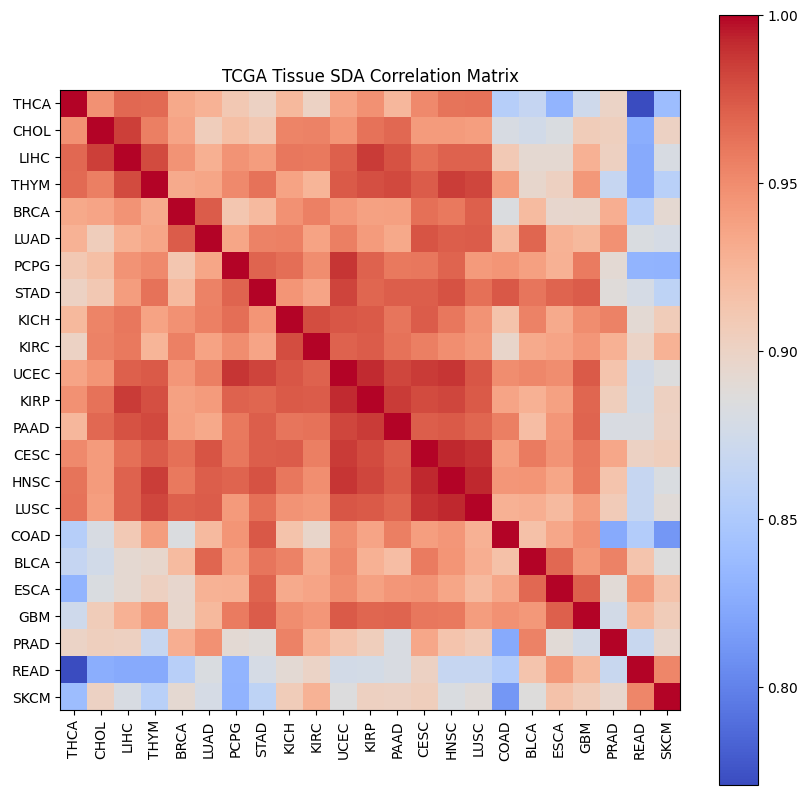

: 

In [ ]:
tissues = test_with_results.columns[25:48]

SDA_vectors = test_with_results[tissues]
corr_matrix = SDA_vectors.corr().to_numpy()

# Compute the linkage matrix
linkage_matrix = linkage(corr_matrix, method='average')

# Extract the index ordering from the linkage matrix
corr_index_order = leaves_list(linkage_matrix)

# Reorder the correlation matrix using the extracted index ordering
reordered_corr_matrix = corr_matrix[corr_index_order, :][:, corr_index_order]

tick_labels = tissues

# Reorder the tick labels
reordered_tick_labels = [tick_labels[i] for i in corr_index_order]

# Plot the reordered correlation matrix
plt.figure(figsize=(10, 10))
plt.imshow(reordered_corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(tissues)), reordered_tick_labels, rotation=90)
plt.yticks(range(len(tissues)), reordered_tick_labels)
plt.title('TCGA Tissue SDA Correlation Matrix')
plt.show()

# SDA vs Codon Fractions Correlation

In [48]:
codon_to_fraction = np.load(os.path.join(data_path, 'codon_to_fraction.npy'), allow_pickle=True).item()

In [49]:
# correlation between codon usage and SDA
tissues = test_with_results.columns[25:48]

In [50]:
# codon fractions
fractions = np.array(list(codon_to_fraction.values()))
codon_names = np.array(list(codon_to_fraction.keys()))

# sort alphabetically
indices = np.argsort(codon_names)
fractions = fractions[indices]
codon_names = codon_names[indices]

# Codon SDA Weights
SDAw = pd.read_csv(os.path.join(data_path, 'SDA', 'SDAw.csv'), index_col=0)

# Remove stop codons
stop_codons = ['TGA', 'TAA', 'TAG']
indices = np.array([(np.where(codon_names == codon)[0][0]) for codon in stop_codons])
fractions = np.delete(fractions, indices)
codon_names = np.delete(codon_names, indices)

# Add start codon ATG to SDAw with weight 1
SDAw['ATG'] = 1

In [51]:
# Calculate the correlation and p-values between codon usage and SDA
correlations = []
p_values = []
for tissue in tissues:
    SDA_weights = SDAw.loc[tissue]
    correlation = np.corrcoef(fractions, SDA_weights.sort_index())[0, 1]
    correlations.append(correlation)
    p_value = ttest_ind(fractions, SDA_weights.sort_index())[1]
    p_values.append(p_value)

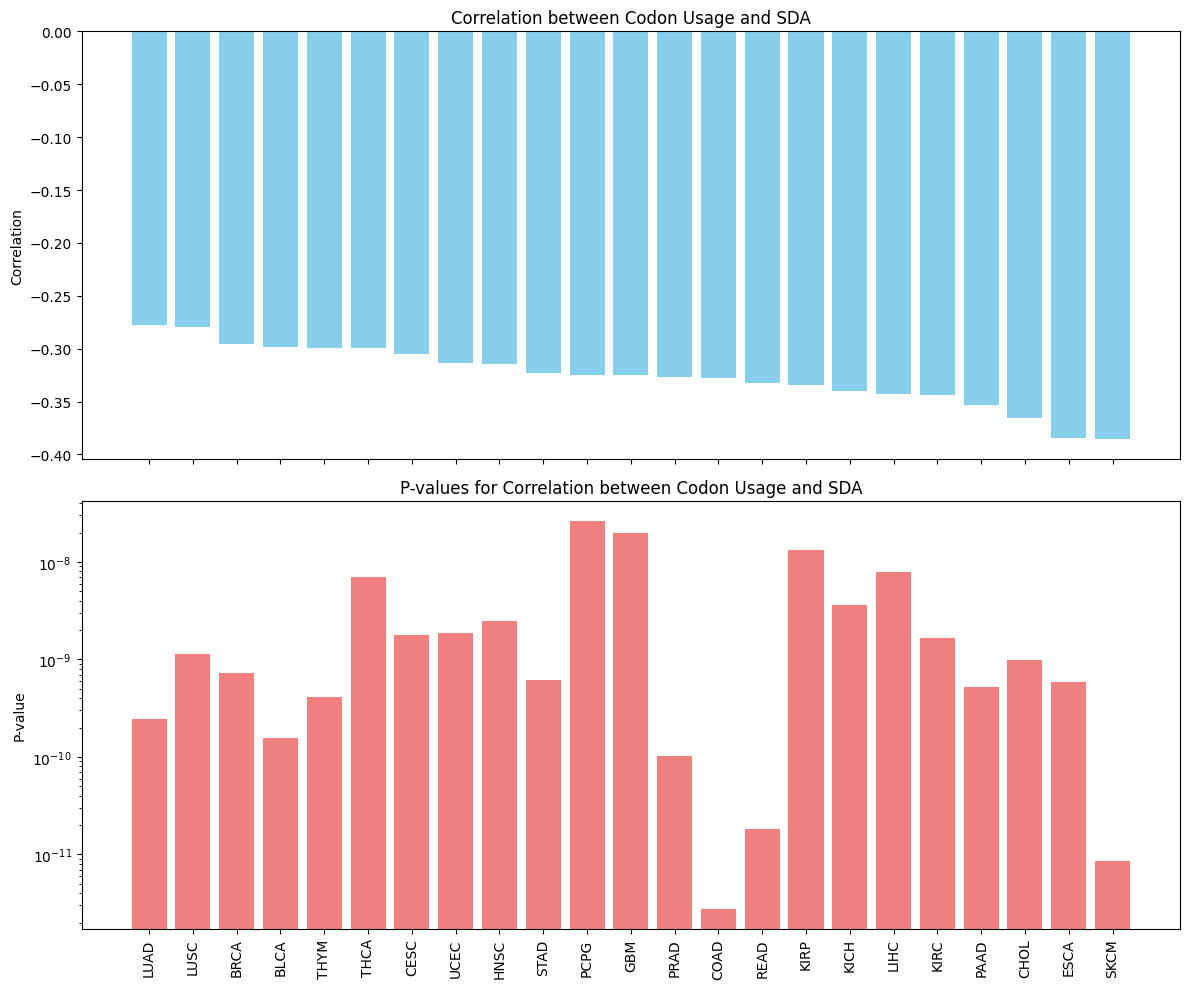

In [52]:
# Graph the correlations and p-values in subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Sort correlations and p-values in descending order
sort_indices = np.argsort(correlations)[::-1]
sorted_correlations = np.array(correlations)[sort_indices]
sorted_p_values = np.array(p_values)[sort_indices]
sorted_tissues = np.array(tissues)[sort_indices]

# Plot correlations
axes[0].bar(sorted_tissues, sorted_correlations, color='skyblue')
axes[0].set_ylabel('Correlation')
axes[0].set_title('Correlation between Codon Usage and SDA')

# Plot p-values
axes[1].bar(sorted_tissues, sorted_p_values, color='lightcoral')
axes[1].set_ylabel('P-value')
axes[1].set_title('P-values for Correlation between Codon Usage and SDA')
axes[1].set_yscale('log')  # Use log scale for p-values

# Rotate x-axis labels
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

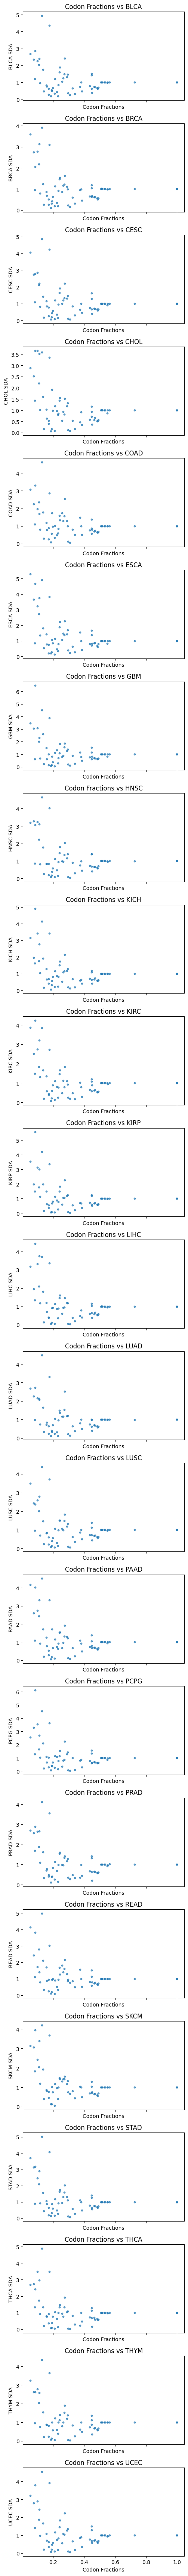

In [53]:
# Create scatterplots for codon fractions against each SDA tissue
fig, axes = plt.subplots(len(tissues), 1, figsize=(5, len(tissues) * 3), sharex=True)

for i, tissue in enumerate(tissues):
    axes[i].scatter(fractions, SDAw.loc[tissue].sort_index(), s=10, alpha=0.7)
    axes[i].set_title(f'Codon Fractions vs {tissue}')
    axes[i].set_xlabel('Codon Fractions')
    axes[i].set_ylabel(f'{tissue} SDA')

plt.tight_layout()
plt.show()


# SDA and Prediction Accuracy

In [ ]:
temp_data = pd.read_csv(os.path.join(data_path, 'genes_human.csv'), delimiter='\t')[['transcript', 'canonical', 'coord_start', 'coord_end', 'exp_T', 'exp_HEK293', 'exp_U2OS', 'cARS_T', 'cARS_HEK293', 'cARS_U2OS']]

merged_data = pd.merge(test_with_results, temp_data, right_on='transcript', left_on='query_transcript', how='left')

test_with_results = merged_data

In [45]:
tissues = test_with_results.columns[25:48]

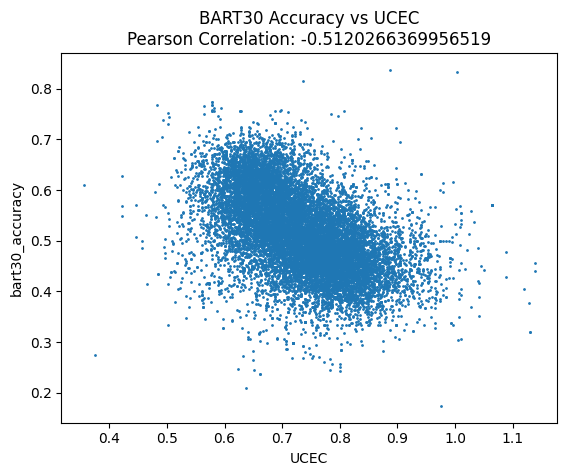

In [123]:
# plot train accuracy vs tissues[0] column
i=22
plt.scatter(test_with_results[tissues[i]], test_with_results['bart30_accuracy'], s=1)
plt.xlabel(tissues[i])
plt.ylabel('bart30_accuracy')
pearson_corr = test_with_results[tissues[i]].corr(test_with_results['bart30_accuracy'])
plt.title('BART30 Accuracy vs ' + tissues[i] + '\nPearson Correlation: ' + str(pearson_corr))
plt.show()

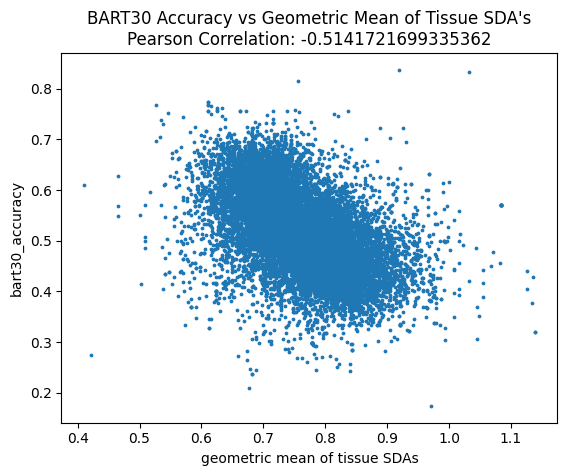

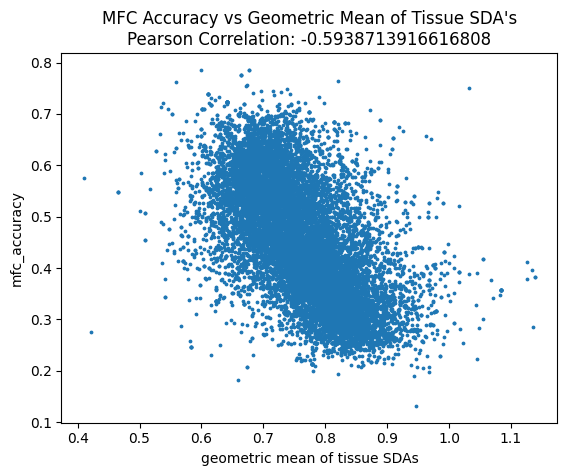

In [119]:
# plot train accuracy vs tissues[0] column
i=22

average_SDA = test_with_results[tissues].apply(lambda x: np.exp(np.mean(np.log(x))), axis=1)

plt.scatter(average_SDA, test_with_results['bart30_accuracy'], s=3)
plt.xlabel('geometric mean of tissue SDAs')
plt.ylabel('bart30_accuracy')
pearson_corr = average_SDA.corr(test_with_results['bart30_accuracy'])
plt.title('BART30 Accuracy vs Geometric Mean of Tissue SDA\'s' + '\nPearson Correlation: ' + str(pearson_corr))
plt.show()

mfc_accuracy = test_with_results['mfc_accuracy']
plt.scatter(average_SDA, mfc_accuracy, s=3)
plt.xlabel('geometric mean of tissue SDAs')
plt.ylabel('mfc_accuracy')
pearson_corr = average_SDA.corr(mfc_accuracy)
plt.title('MFC Accuracy vs Geometric Mean of Tissue SDA\'s' + '\nPearson Correlation: ' + str(pearson_corr))
plt.show()

In [89]:
# sort by sequence average pident
sorted_df = test_with_results.sort_values(by='bart30_accuracy')

bart30_accuracy = sorted_df['bart30_accuracy']

# group by sequence lengths and calculate the average of the accuracy columns
bart30_grouped = sorted_df.groupby(bart30_accuracy)
# average each SDA column with geometric mean
# average_SDA_per_exp = np.exp(np.mean(np.log(grouped[tissues]), axis=1))

# average each SDA column with arithmetic mean
bart30_grouped_means = bart30_grouped[tissues].mean()

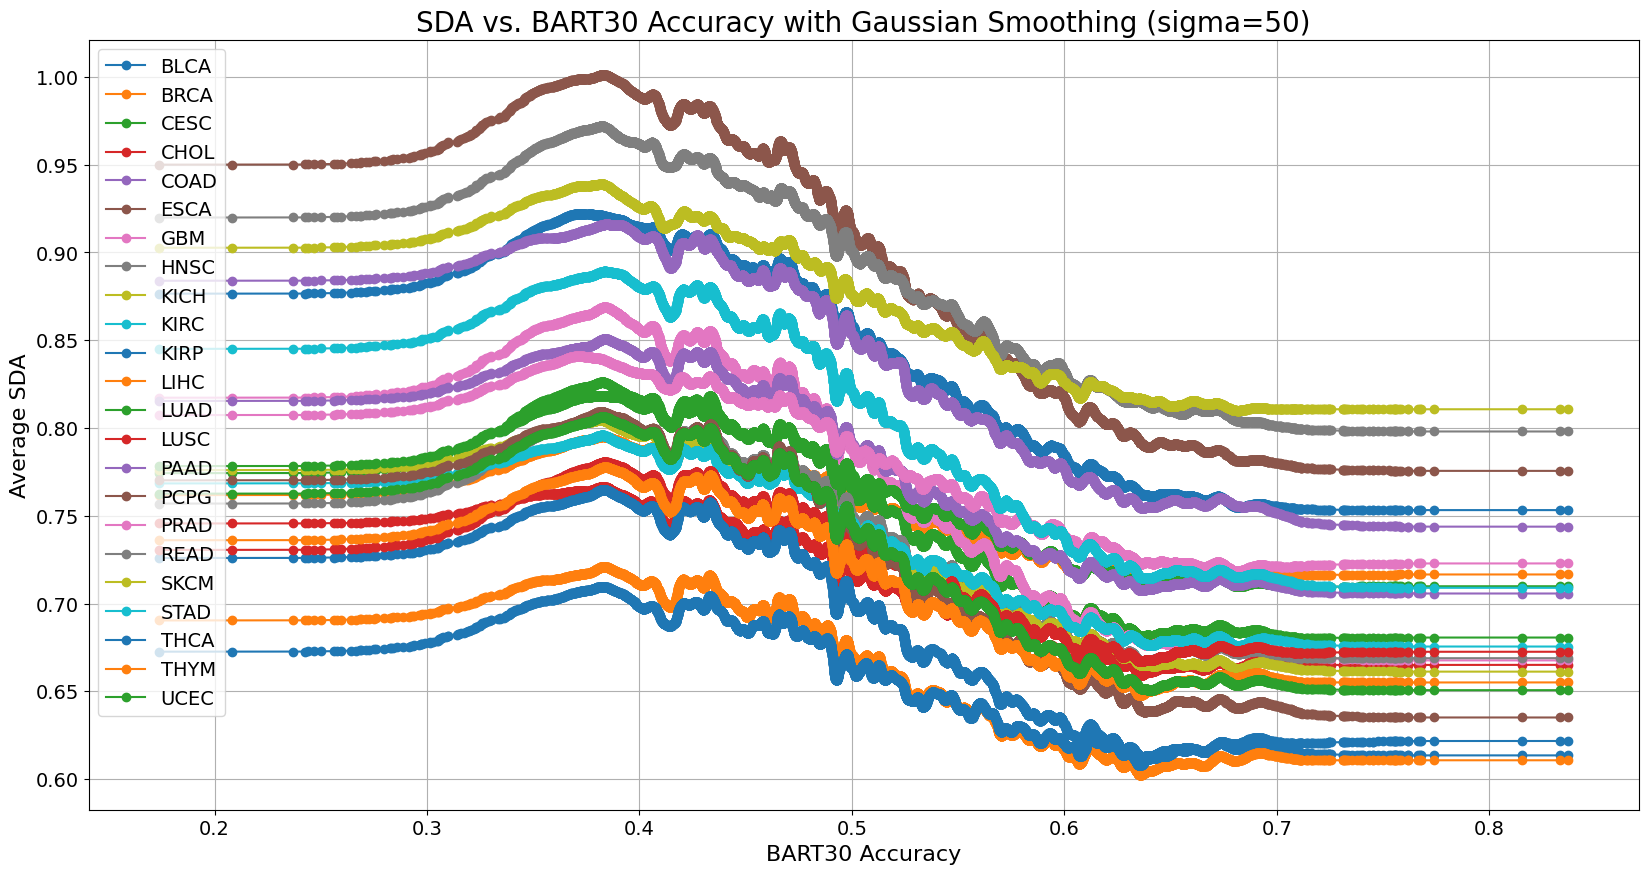

In [90]:
# For Gaussian smoothing
sgma = 50

plt.figure(figsize=(20, 10))

for tissue in tissues:
    smoothed_SDA = gaussian_filter1d(bart30_grouped_means[tissue], sigma=sgma)
    plt.plot(bart30_grouped_means.index, smoothed_SDA, marker='o', alpha=1, label=tissue)

plt.title(f"SDA vs. BART30 Accuracy with Gaussian Smoothing (sigma={sgma})", fontsize=20)
plt.xlabel('BART30 Accuracy', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Average SDA', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

In [91]:
# sort by sequence average pident
sorted_df = test_with_results.sort_values(by='mfc_accuracy')

mfc_accuracy = sorted_df['mfc_accuracy']

# group by sequence lengths and calculate the average of the accuracy columns
mfc_grouped = sorted_df.groupby(mfc_accuracy)
# average each SDA column with geometric mean
# average_SDA_per_exp = np.exp(np.mean(np.log(grouped[tissues]), axis=1))

# average each SDA column with arithmetic mean
mfc_grouped_means = mfc_grouped[tissues].mean()

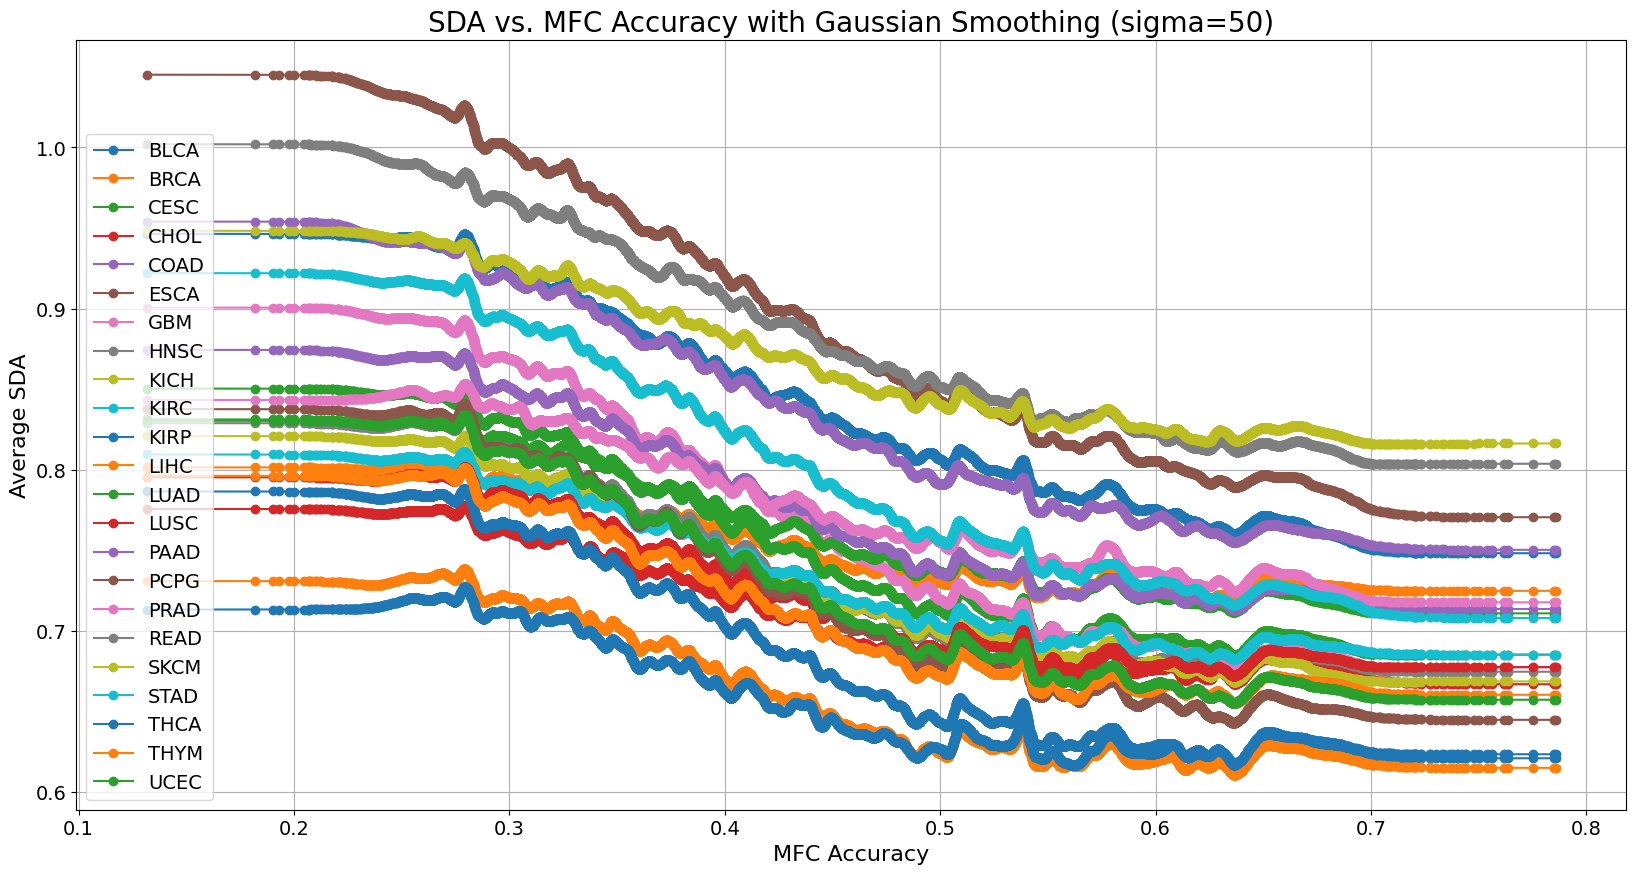

In [109]:
# For Gaussian smoothing
sgma = 50

plt.figure(figsize=(20, 10))

for tissue in tissues:
    smoothed_SDA = gaussian_filter1d(mfc_grouped_means[tissue], sigma=sgma)
    plt.plot(mfc_grouped_means.index, smoothed_SDA, marker='o', alpha=1, label=tissue)

plt.title(f"SDA vs. MFC Accuracy with Gaussian Smoothing (sigma={sgma})", fontsize=20)
plt.xlabel('MFC Accuracy', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Average SDA', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

# Random Forest

In [ ]:
# Train test split (0.5 train, 0.5 test)
train = test_with_results.sample(frac=0.5, random_state=42)
test = test_with_results.drop(train.index)

# Random forest X data
tissues = test_with_results.columns[25:48]
train_X = train[tissues]

# replace all values in tissues columns with random values
# for tissue in tissues:
#     train_X[tissue] = np.random.rand(len(train_X))

# Random forest y data
train_y = train['bart30_accuracy']

# Random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf.fit(train_X, train_y)

RandomForestRegressor(random_state=42)

In [52]:
train.head()

,cluster,length (aa),query_gene,query_transcript,seq,amino_acid_seq,median,subject_transcript,average_pident,gene,...,LUSC,PAAD,PCPG,PRAD,READ,SKCM,STAD,THCA,THYM,UCEC
1768,9156,42,ENSG00000170006,ENST00000705348,ATGGAAATTGAAATGGAAGAGCTTGATAAATGGATGAACAGCATGA...,MEIEMEELDKWMNSMNRNADFECLPTLKEEKESNHNPSDSES*,NaN,NaN,0.000000,ENSG00000170006,...,0.764492,0.797822,0.811265,0.840105,0.908178,0.853081,0.855342,0.717922,0.750221,0.794494
1533,2921,731,ENSG00000116514,ENST00000235150,ATGGGCTCCGAGAAGGACTCCGAGTCGCCGCGCTCCACATCGCTAC...,MGSEKDSESPRSTSLHAAAPDPKCRSGGRRRRLTLHSVFSASARGR...,"(expr_pre75_90, expr_pre75_90, expr_pre75_90, ...",ENST00000259939,10.151494,ENSG00000116514,...,0.729328,0.784590,0.709393,0.765252,0.906999,0.884839,0.794835,0.658375,0.717488,0.721580
9129,4456,598,ENSG00000153234,ENST00000339562,ATGCCTTGTGTTCAGGCGCAGTATGGGTCCTCGCCTCAAGGAGCCA...,MPCVQAQYGSSPQGASPASQSYSYHSSGEYSSDFLTPEFVKFSMDL...,"(expr_pre75_90, expr_top10, expr_pre75_90, exp...",ENST00000618101,54.809000,ENSG00000153234,...,0.665386,0.723373,0.667595,0.759735,0.852917,0.829648,0.735765,0.587139,0.634571,0.670253
13765,5286,94,ENSG00000110324,ENST00000526544,ATGCTGCCGTGCCTCGTAGTGCTGCTGGCGGCGCTCCTCAGCCTCC...,MLPCLVVLLAALLSLRLGSDAHGTELPSPPSVWFEAEFFHHILHWT...,"(expr_low25, expr_low25, expr_low25, expr_low2...",NaN,0.000000,ENSG00000110324,...,0.630913,0.642014,0.619422,0.725242,0.795298,0.779652,0.697586,0.573209,0.590376,0.626274
11183,2415,53,ENSG00000139687,ENST00000467505,ATGCCGCCCAAAACCCCCCGAAAAACGGCCGCCACCGCCGCCGCTG...,MPPKTPRKTAATAAAAAAEPPAPPPPPPPEEDPEQDSGPEDLPLVR...,"(expr_low25, expr_low25, expr_low25, expr_low2...",NaN,0.000000,ENSG00000139687,...,0.649812,0.703240,0.539897,0.773144,0.986964,0.960033,0.687749,0.539555,0.591408,0.603812


In [41]:
# Predict
test_X = test[tissues]
test_y = test['bart30_accuracy']
predicted_y = rf.predict(test_X)

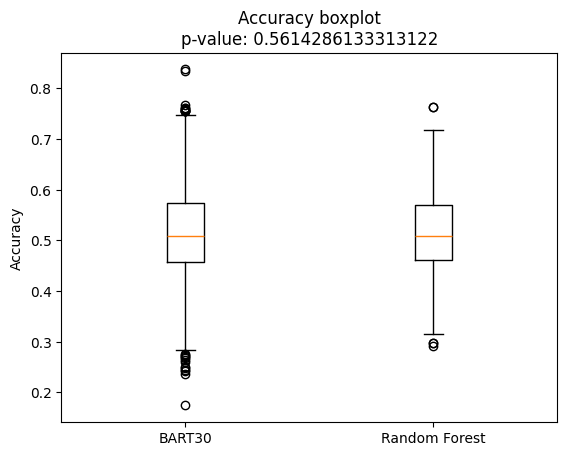

In [115]:
# p-value
temp_test_y = test['bart30_accuracy']
p_value = ttest_ind(temp_test_y, predicted_y).pvalue

# boxplot of y and predicted y
plt.boxplot([test_y, predicted_y])
plt.xticks([1, 2], ['BART30', 'Random Forest'])
plt.title(f'Accuracy boxplot\np-value: {p_value}')
plt.ylabel('Accuracy')
plt.show()

In [44]:
rf.predict(0.6 * np.ones(len(tissues)).reshape(1, -1))

C:\Users\wsega\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([0.6120199])

# Linear Regression

In [3]:
# Train test split (0.5 train, 0.5 test)
train = test_with_results.sample(frac=0.5, random_state=42)
test = test_with_results.drop(train.index)

# Linear regression X data
tissues = test_with_results.columns[25:48]
train_X = train[tissues]

# replace all values in tissues columns with random values
# for tissue in tissues:
#     train_X[tissue] = np.random.rand(len(train_X))

# Linear regression y data
train_y = train['bart30_accuracy']

In [4]:
# Linear regression model
lr = LinearRegression()

# Fit the model
lr.fit(train_X, train_y)

LinearRegression()

In [6]:
# Predict
test_X = test[tissues]
test_y = test['bart30_accuracy']
predicted_y = lr.predict(test_X)

In [11]:
# calculate variance between predicted and actual values
variance = np.var(predicted_y - test_y)
variance

np.float64(0.001964233718696443)

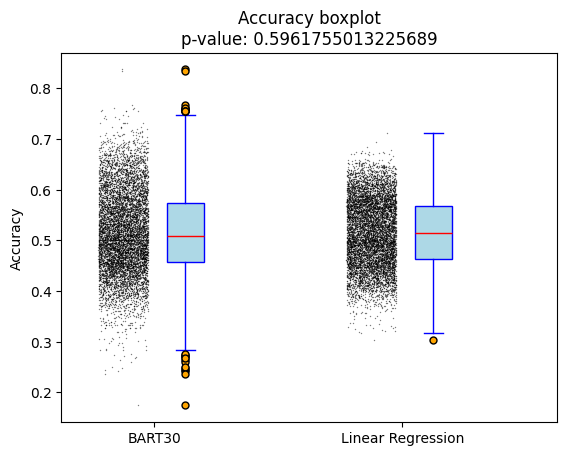

In [ ]:
import seaborn as sns

# p-value
temp_test_y = test['bart30_accuracy']
# perform student's t-test
p_value = ttest_ind(temp_test_y, predicted_y).pvalue

# Add stripplot with explicit x positions to align with boxplot
sns.stripplot(data=[test_y, predicted_y],
              jitter=True, dodge=False, color='black', alpha=0.5, s=1)


# boxplot of y and predicted y
plt.boxplot([test_y, predicted_y], patch_artist=True, 
            positions=[0.25, 1.25],
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))

# Add stripplot

plt.xticks([0.125, 1.125], ['BART30', 'Linear Regression'])
plt.title(f'Accuracy boxplot\np-value: {p_value}')
plt.ylabel('Accuracy')
plt.show()

# SDA and Cancer Expression

In [ ]:
tissues = test_with_results.columns[25:48]

In [19]:
test_with_results.columns

Index(['cluster', 'length (aa)', 'query_gene', 'query_transcript', 'seq',
       'amino_acid_seq', 'median', 'subject_transcript', 'average_pident',
       'gene', 'transcript_x', 'median_float', 'mfc_prediction',
       'mfc_accuracy', 'mfb_prediction', 'mfb_accuracy',
       'exp_harmonized_prediction', 'exp_harmonized_accuracy', 'transcript_y',
       'bart30_prediction', 'bart30_entropy',
       'bart30_num_of_correct_predicted_codons', 'bart30_cross_entropy_loss',
       'bart30_perplexity', 'bart30_accuracy', 'BLCA', 'BRCA', 'CESC', 'CHOL',
       'COAD', 'ESCA', 'GBM', 'HNSC', 'KICH', 'KIRC', 'KIRP', 'LIHC', 'LUAD',
       'LUSC', 'PAAD', 'PCPG', 'PRAD', 'READ', 'SKCM', 'STAD', 'THCA', 'THYM',
       'UCEC', 'transcript', 'canonical', 'coord_start', 'coord_end', 'exp_T',
       'exp_HEK293', 'exp_U2OS', 'cARS_T', 'cARS_HEK293', 'cARS_U2OS'],
      dtype='object')

In [ ]:
# sort by sequence average pident
sorted_df = test_with_results.sort_values(by='exp_HEK293')

HEK293_expression = sorted_df['exp_HEK293']

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(HEK293_expression)
# average each SDA column with geometric mean
# average_SDA_per_exp = np.exp(np.mean(np.log(grouped[tissues]), axis=1))

# average each SDA column with arithmetic mean
grouped_means = grouped[tissues].mean()

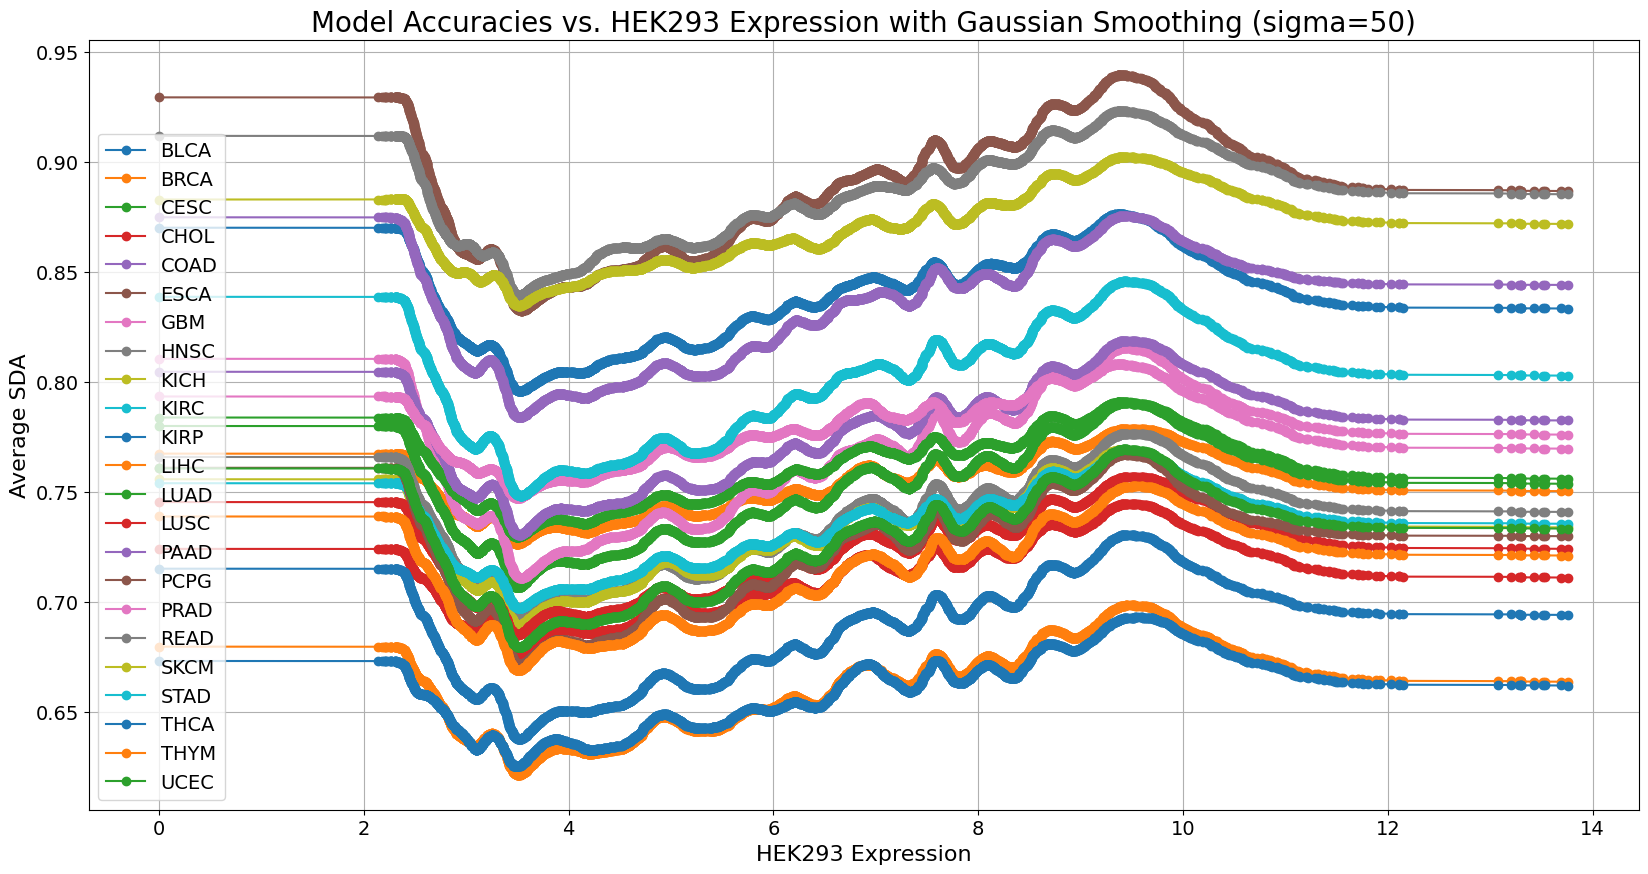

In [76]:
# For Gaussian smoothing
sgma = 50

plt.figure(figsize=(20, 10))

for i in range(len(tissues)):
    smoothed_SDA = gaussian_filter1d(grouped_means[tissues[i]], sigma=sgma)
    plt.plot(grouped_means.index, smoothed_SDA, marker='o', alpha=1, label=tissues[i])

plt.title(f"Model Accuracies vs. HEK293 Expression with Gaussian Smoothing (sigma={sgma})", fontsize=20)
plt.xlabel('HEK293 Expression', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Average SDA', fontsize=16)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

# SDA Values and Tissue Expression

In [ ]:
# SDA values
SDA_vectors = test_with_results[tissues].to_numpy()

# Expression Values
log_expression_vectors = np.stack(test_with_results['median_float'].dropna())

# Correlation Matrix
correlation_matrix = np.corrcoef(SDA_vectors, log_expression_vectors)

In [70]:
# Expression Values
kept_indices = test_with_results['median_float'].dropna().index
log_expression_vectors = np.log(np.stack(test_with_results['median_float'].dropna().values) + np.exp(-2))
dim_expression = log_expression_vectors.shape[1]

# SDA values
SDA_vectors = test_with_results.loc[kept_indices, tissues].to_numpy()
dim_SDA = SDA_vectors.shape[1]

# 
combined_vectors = np.hstack([log_expression_vectors, SDA_vectors])

# Correlation Matrix
correlation_matrix = np.corrcoef(combined_vectors, rowvar=False)  # the columns are the variables

# Extract the d_X x d_Y block
corr_SDAvsExp = correlation_matrix[:dim_expression, dim_expression:]  # Shape (d_X, d_Y)


In [ ]:
# np flatten
pd.Series(np.ravel(np.stack(test_with_results['median_float'].dropna().values))).value_counts()

C:\Users\wsega\AppData\Local\Temp\ipykernel_21732\343336173.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(np.ravel(np.stack(test_with_results['median_float'].dropna().values)))


0.000000      261062
0.020000        4802
0.030000        4549
0.040000        4497
0.050000        4288
               ...  
170.690002         1
30.689999          1
53.190002          1
89.500000          1
53.010002          1
Name: count, Length: 21082, dtype: int64

In [84]:
expression_tissue_names = discretized_df = pd.read_pickle(os.path.join(data_path, 'genes_human_discrete_expression.pkl')).loc[0, 'tissueSiteDetailId']
SDA_tissue_names = tissues

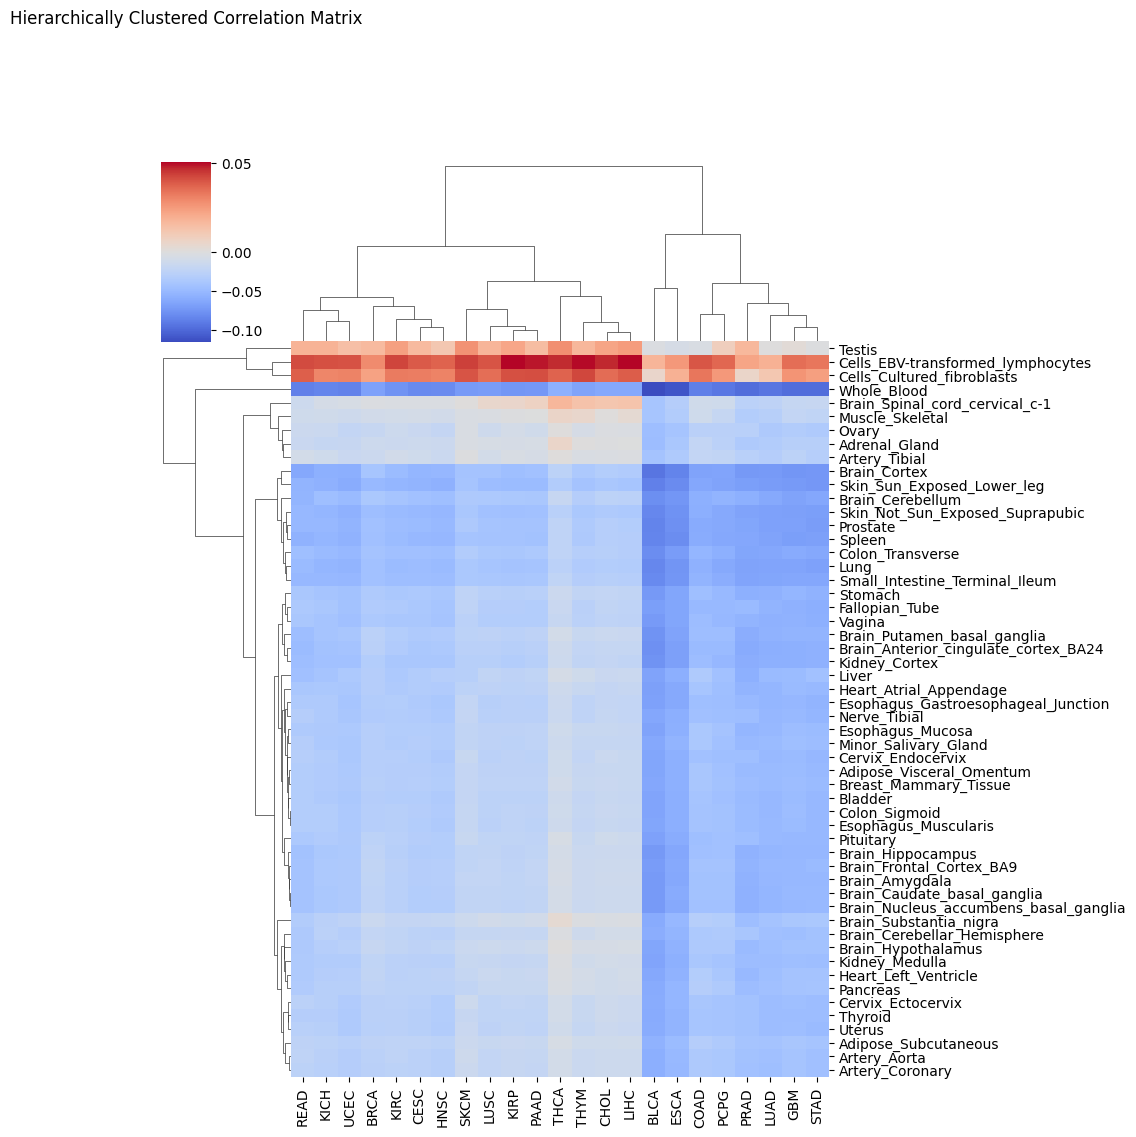

In [92]:
from matplotlib.colors import TwoSlopeNorm

# Ensure corr_SDAvsExp is a DataFrame for clustermap
corr_SDAvsExp_df = pd.DataFrame(corr_SDAvsExp)

# Use seaborn's clustermap for hierarchical clustering and visualization
sns.clustermap(
    corr_SDAvsExp_df,
    method='average',
    cmap='coolwarm',
    figsize=(10, 10),
    annot=False,
    xticklabels=SDA_tissue_names,
    yticklabels=expression_tissue_names,
    norm=TwoSlopeNorm(vcenter=0)  # Center 0 as white
)

plt.title('Hierarchically Clustered Correlation Matrix', pad=100)
plt.show()

In [33]:
# Example data: N samples of X (dim d_X) and Y (dim d_Y)
N = 100  # Number of samples
d_X = 3  # Dimensions of X
d_Y = 2  # Dimensions of Y

X = np.random.rand(N, d_X)  # 100 samples of a 3D vector
Y = np.random.rand(N, d_Y)  # 100 samples of a 2D vector

# Compute correlation matrix
combined = np.hstack([X, Y])  # Shape (N, d_X + d_Y)
corr_matrix = np.corrcoef(combined, rowvar=False)  # Full correlation matrix

# Extract the d_X x d_Y block
corr_XY = corr_matrix[:d_X, d_X:]  # Shape (d_X, d_Y)

print("Correlation matrix between X and Y:\n", corr_XY)

Correlation matrix between X and Y:
 [[ 0.06100864 -0.02877423]
 [-0.10896784 -0.2789267 ]
 [ 0.08629105  0.11130829]]


In [31]:
np.log(np.stack(test_with_results['median_float'].dropna()) + np.exp(-10))

array([[  1.0578061 ,   0.40549537,   0.82857163, ...,  -0.96746457,
          0.20297792,  -3.50504573],
       [ -3.50504573,  -3.9097556 ,  -2.65861167, ...,  -2.30213118,
         -2.99482467, -10.        ],
       [ -1.83229778,  -1.30916515,  -0.14497328, ...,  -0.86739251,
         -0.754926  , -10.        ],
       ...,
       [  2.31055776,   2.08691924,   1.93514464, ...,   2.71602137,
          2.3758398 ,   0.55391121],
       [-10.        , -10.        ,  -4.60064049, ..., -10.        ,
         -3.9097556 , -10.        ],
       [-10.        ,  -1.77168981,  -1.56043161, ...,  -0.54464893,
         -1.23771774, -10.        ]])